In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

np.random.seed(42)

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )

def mase(y_true, y_pred, y_train):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train = np.array(y_train)

    naive_error = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / naive_error

def theil_u(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2) + np.mean(y_pred ** 2))
    u = rmse / denominator
    return u

# Load dataset
df = pd.read_excel('output_week.xlsx')

# Count records and sort by week
data = df['WEEK'].value_counts().reset_index()
data.columns = ['WEEK', 'DATA']

# Convert week identifier to a date representing the beginning of the week
data['WEEK_period'] = pd.to_datetime(
    data['WEEK'] + '-1',
    format='%G-%V-%u',
    errors='coerce'
)
data = data.sort_values('WEEK_period').reset_index(drop=True)

# ------------------------------
# Smoothing (moving average)
# ------------------------------
data['DATA_smooth'] = data['DATA'].rolling(
    window=5,
    center=True
).mean()

data['DATA_smooth'].fillna(method='bfill', inplace=True)
data['DATA_smooth'].fillna(method='ffill', inplace=True)

# Data normalization
scaler = MinMaxScaler(feature_range=(0.1, 1))
data['y'] = scaler.fit_transform(data[['DATA_smooth']])

# ------------------------------
# Create lagged features
# ------------------------------
n_lags = 11  # Alternative values such as 12, 16, or 26 may also be tested

for i in range(1, n_lags + 1):
    data[f'lag_{i}'] = data['y'].shift(i)

data = data.dropna().reset_index(drop=True)

# ------------------------------
# Prepare X and y
# ------------------------------
lag_cols = [f'lag_{i}' for i in range(n_lags, 0, -1)]

X = data[lag_cols].values.astype(np.float32)
y = data['y'].values.astype(np.float32)

# Reshape for GRU input
X = X.reshape((X.shape[0], X.shape[1], 1))

# ------------------------------
# Train/Test Split
# ------------------------------
split = int(len(X) * 0.7)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_3268/1112446314.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_3268/1112446314.py:56: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_3268/111244631

In [8]:
# ------------------------------
# Create GRU Model
# ------------------------------
model = Sequential()

# First GRU layer
model.add(
    GRU(
        units=256,
        activation='tanh',
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.1))

# Second GRU layer
model.add(
    GRU(
        units=256,
        activation='tanh'
    )
)

model.add(Dropout(0.1))

# Output layer
model.add(Dense(1, activation='linear'))

# Model compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------
# Model Evaluation
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# Evaluation Metrics
# ------------------------------
smape_value = smape(y_test, y_pred)
mase_value = mase(y_test, y_pred, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Normalized MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# MAPE on the original scale
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

mape_real = np.mean(
    np.abs((y_test_real - y_pred_real) / y_test_real)
) * 100

u1 = theil_u(y_test, y_pred)

Epoch 1/100


/Users/octaciliofsilvajunior/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0701 - val_loss: 0.0040
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0093 - val_loss: 0.0015
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0057 - val_loss: 0.0014
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0056 - val_loss: 0.0013
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0053 - val_loss: 0.0012
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0045 - val_loss: 0.0012
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0035 - val_loss: 0.0010
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0039 - val_loss: 9.5872e-04
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0030 - val_loss: 8.6117e-04
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - l

RMSE: 0.0301
R²: 0.8553
MAPE (normalized): 39.78%
MAPE (original scale): 9.20%
sMAPE: 35.10%
MASE: 2.5480
Theil's U1: 0.29741982
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


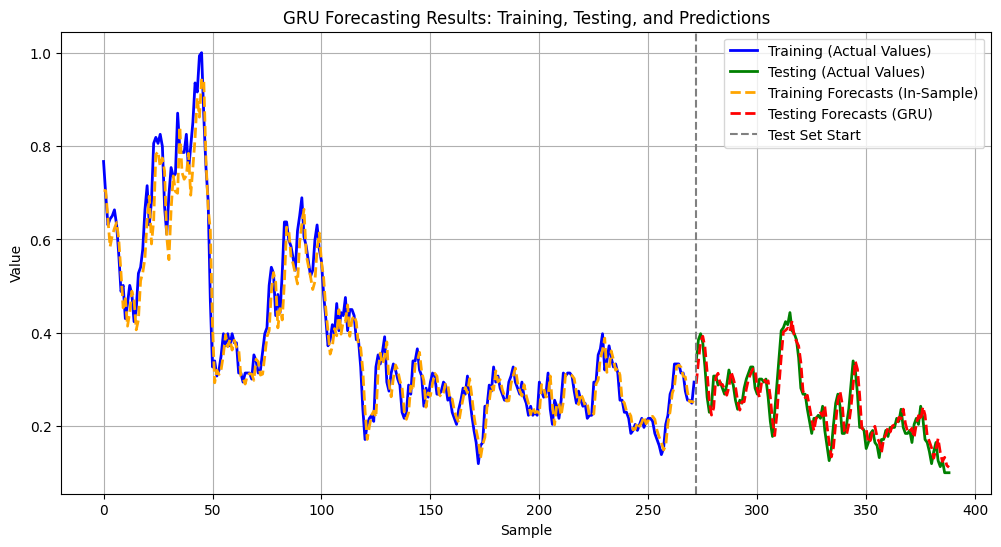

In [9]:
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE (normalized): {mape:.2f}%")
print(f"MAPE (original scale): {mape_real:.2f}%")
print(f"sMAPE: {smape_value:.2f}%")
print(f"MASE: {mase_value:.4f}")
print("Theil's U1:", u1)

y_pred_train = model.predict(X_train)

plt.figure(figsize=(12, 6))

# Indices
idx_train = np.arange(len(y_train))
idx_test = np.arange(len(y_train), len(y_train) + len(y_test))

# ---------------------------
# ACTUAL VALUES
# ---------------------------

# Training actual values
plt.plot(
    idx_train,
    y_train,
    label='Training (Actual Values)',
    color='blue',
    linewidth=2
)

# Testing actual values
plt.plot(
    idx_test,
    y_test,
    label='Testing (Actual Values)',
    color='green',
    linewidth=2
)

# ---------------------------
# FORECASTS
# ---------------------------

# In-sample forecasts
plt.plot(
    idx_train,
    y_pred_train,
    label='Training Forecasts (In-Sample)',
    color='orange',
    linestyle='--',
    linewidth=2
)

# Out-of-sample forecasts
plt.plot(
    idx_test,
    y_pred,
    label='Testing Forecasts (GRU)',
    color='red',
    linestyle='--',
    linewidth=2
)

# ---------------------------
# TRAIN/TEST SPLIT LINE
# ---------------------------

plt.axvline(
    x=len(y_train),
    color='gray',
    linestyle='--',
    label='Test Set Start'
)

plt.title('GRU Forecasting Results: Training, Testing, and Predictions')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#Hyperparameter optimization was performed using a Random Search strategy.

import tensorflow as tf
def criar_gru(hidden_size, num_layers, dropout):

    model = Sequential()

    for i in range(num_layers):

        return_sequences = i < num_layers - 1

        model.add(
            GRU(
                units=hidden_size,
                return_sequences=return_sequences
            )
        )

        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1))

    return model

from sklearn.metrics import mean_squared_error

def treinar_e_validar(
    model,
    X_tr,
    y_tr,
    X_val,
    y_val,
    lr,
    batch_size
):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="mse"
    )

    model.fit(
        X_tr,
        y_tr,
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )

    pred = model.predict(X_val)

    mse1 = mean_squared_error(
    y_val,
    pred
)

    rmse1 = np.sqrt(mse1)

    return rmse1

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False  # importante para séries temporais
)

param_space = {
    "hidden_size": [32, 64, 128, 256],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3],
    "lr": [1e-4, 5e-4, 1e-3],
    "batch_size": [16, 32, 64]
}

from sklearn.model_selection import ParameterSampler

configs = list(
    ParameterSampler(
        param_space,
        n_iter=20,
        random_state=42
    )
)

best_loss = float("inf")
best_params = None

for params in configs:

    model = criar_gru(
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"]
    )

    loss = treinar_e_validar(
        model,
        X_tr,
        y_tr,
        X_val,
        y_val,
        lr=params["lr"],
        batch_size=params["batch_size"]
    )

    if loss < best_loss:
        best_loss = loss
        best_params = params

print(best_params)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
{'num_layers': 2, 'lr': 0.001, 'hidden_size': 256, 'dropout': 0.1, 'batch_size': 16}
